In [26]:
import sys
print(sys.executable)

C:\Users\Neik Singh\anaconda3\envs\ctdenoise\python.exe


In [27]:
import torch
import pydicom
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cpu
CUDA available: False


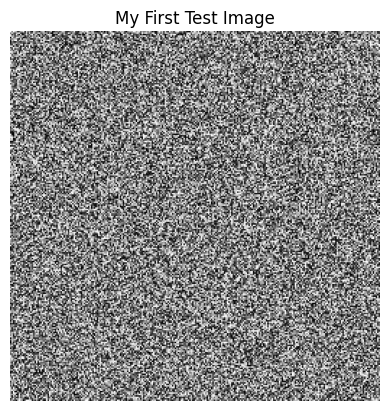

In [28]:
import numpy as np
import matplotlib.pyplot as plt

image = np.random.rand(256, 256)

plt.imshow(image, cmap="gray")
plt.title("My First Test Image")
plt.axis("off")
plt.show()

In [29]:
import pydicom
import matplotlib.pyplot as plt

file_path = r"C:\Users\Neik Singh\Desktop\CT_Denoising_Project\data\raw_dicom\your_file.dcm"

ds = pydicom.dcmread(file_path)

image = ds.pixel_array

plt.imshow(image, cmap="gray")
plt.title("Original CT DICOM Image")
plt.axis("off")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Neik Singh\\Desktop\\CT_Denoising_Project\\data\\raw_dicom\\your_file.dcm'

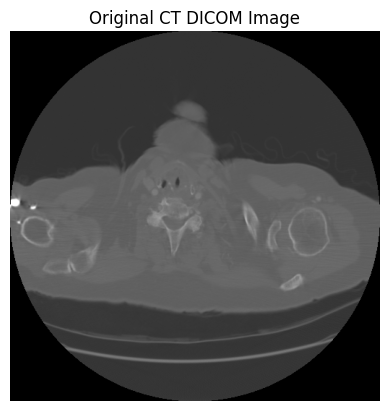

In [34]:
import pydicom
import matplotlib.pyplot as plt

file_path = r"C:\Users\Neik Singh\Desktop\CT_Denoising_Project\data\raw_dicom\1-001.dcm"

ds = pydicom.dcmread(file_path)

image = ds.pixel_array

plt.imshow(image, cmap="gray")
plt.title("Original CT DICOM Image")
plt.axis("off")
plt.show()

In [35]:
print(ds)


Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 206
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.14519.5.2.1.6279.6001.262721256650280657946440242654
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.22213.1.143
(0002,0013) Implementation Version Name         SH: '0.5'
(0002,0016) Source Application Entity Title     AE: 'POSDA'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.14519.5.2.1.6279.6001.26272125665028065

In [36]:
# Convert raw pixels to float
image = image.astype(float)

# Get slope and intercept from metadata
slope = ds.RescaleSlope
intercept = ds.RescaleIntercept

# Convert to Hounsfield Units
hu_image = image * slope + intercept

# Print HU range
print("Minimum HU:", hu_image.min())
print("Maximum HU:", hu_image.max())

Minimum HU: -2048.0
Maximum HU: 3071.0


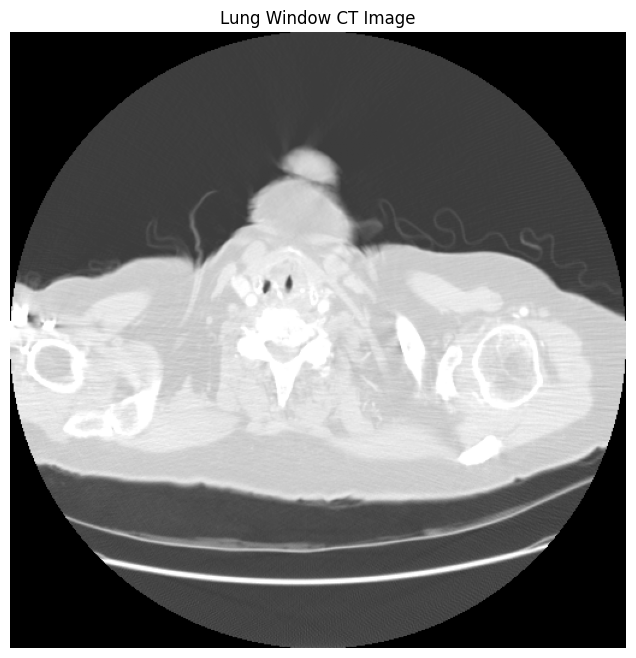

In [37]:
# Lung window parameters
window_center = -600
window_width = 1600

# Calculate window limits
lower = window_center - window_width // 2
upper = window_center + window_width // 2

# Clip HU values to window
windowed_image = np.clip(hu_image, lower, upper)

# Display image
plt.figure(figsize=(8,8))
plt.imshow(windowed_image, cmap='gray')
plt.title("Lung Window CT Image")
plt.axis("off")
plt.show()

In [38]:
#Normalize windowed image
import numpy as np
import matplotlib.pyplot as plt

clean_image = windowed_image.copy()

clean_norm = (clean_image - clean_image.min()) / (clean_image.max() - clean_image.min())

print(clean_norm.min())
print(clean_norm.max())

0.0
1.0


In [39]:
#add Gaussian noise
noise = np.random.normal(0, 0.08, clean_norm.shape)

noisy_image = clean_norm + noise

noisy_image = np.clip(noisy_image, 0, 1)

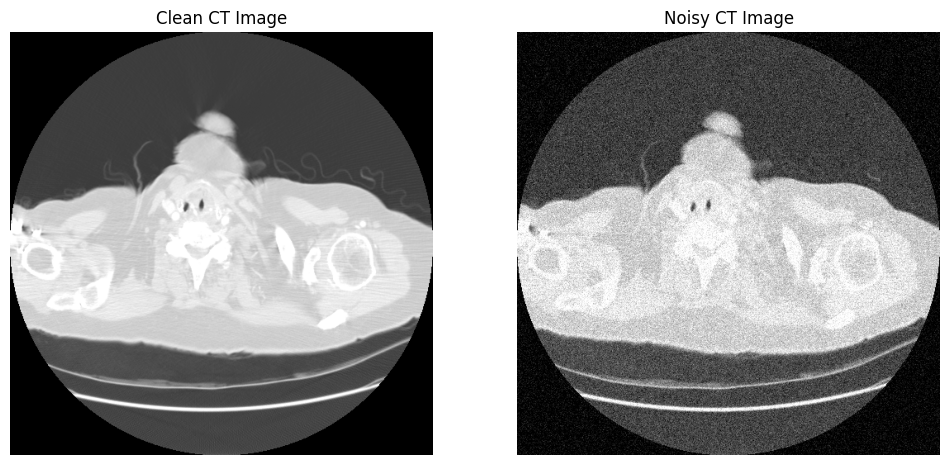

In [40]:

#show clean v/s noisy
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(clean_norm, cmap="gray")
plt.title("Clean CT Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(noisy_image, cmap="gray")
plt.title("Noisy CT Image")
plt.axis("off")

plt.show()

In [41]:
import torch

# Convert NumPy arrays to PyTorch tensors
clean_tensor = torch.tensor(clean_norm, dtype=torch.float32)
noisy_tensor = torch.tensor(noisy_image, dtype=torch.float32)

print(clean_tensor.shape)
print(noisy_tensor.shape)

torch.Size([512, 512])
torch.Size([512, 512])


In [42]:
# Add channel and batch dimensions
clean_tensor = clean_tensor.unsqueeze(0).unsqueeze(0)
noisy_tensor = noisy_tensor.unsqueeze(0).unsqueeze(0)

print(clean_tensor.shape)
print(noisy_tensor.shape)

torch.Size([1, 1, 512, 512])
torch.Size([1, 1, 512, 512])


In [43]:
import torch.nn as nn

class SimpleDenoiser(nn.Module):

    def __init__(self):
        super(SimpleDenoiser, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=1,
            kernel_size=3,
            padding=1
        )

    def forward(self, x):

        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)

        return x


model = SimpleDenoiser()

print(model)

SimpleDenoiser(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (conv2): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


In [44]:
import torch.optim as optim

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Number of training iterations
epochs = 200

for epoch in range(epochs):

    # Forward pass
    output = model(noisy_tensor)

    # Compare output with clean target
    loss = criterion(output, clean_tensor)

    # Clear old gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    # Print progress
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

Epoch [20/200], Loss: 0.019377
Epoch [40/200], Loss: 0.002622
Epoch [60/200], Loss: 0.001884
Epoch [80/200], Loss: 0.001486
Epoch [100/200], Loss: 0.001274
Epoch [120/200], Loss: 0.001166
Epoch [140/200], Loss: 0.001109
Epoch [160/200], Loss: 0.001068
Epoch [180/200], Loss: 0.001007
Epoch [200/200], Loss: 0.000922


In [46]:
model.eval()

with torch.no_grad():
    denoised_tensor = model(noisy_tensor)

denoised_image = denoised_tensor.squeeze().numpy()

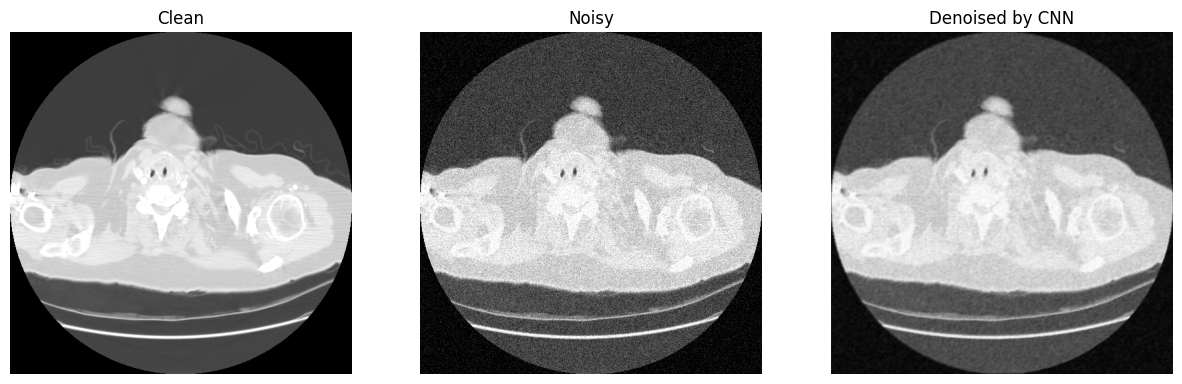

In [47]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(clean_norm, cmap="gray")
plt.title("Clean")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(noisy_image, cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(denoised_image, cmap="gray")
plt.title("Denoised by CNN")
plt.axis("off")

plt.show()

In [48]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

psnr_noisy = peak_signal_noise_ratio(clean_norm, noisy_image, data_range=1)
psnr_denoised = peak_signal_noise_ratio(clean_norm, denoised_image, data_range=1)

ssim_noisy = structural_similarity(clean_norm, noisy_image, data_range=1)
ssim_denoised = structural_similarity(clean_norm, denoised_image, data_range=1)

print("PSNR Noisy:", psnr_noisy)
print("PSNR Denoised:", psnr_denoised)

print("SSIM Noisy:", ssim_noisy)
print("SSIM Denoised:", ssim_denoised)

PSNR Noisy: 22.660579827895045
PSNR Denoised: 30.372927094617136
SSIM Noisy: 0.254026392781824
SSIM Denoised: 0.7103116349074023


In [49]:
import os

print(os.getcwd())

C:\Users\Neik Singh\Desktop\CT_Denoising_Project\Notebook


In [51]:
plt.savefig("../figures/denoising_results.png", dpi=300)

<Figure size 640x480 with 0 Axes>

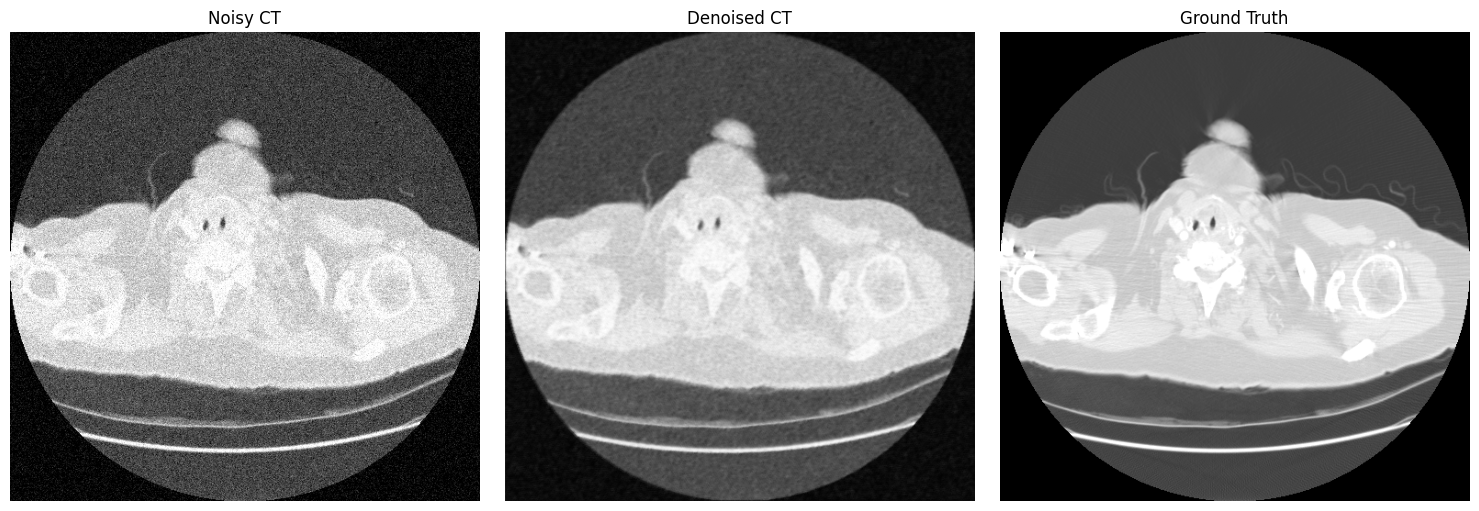

In [54]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,3, figsize=(15,5))

axes[0].imshow(noisy_image.squeeze(), cmap='gray')
axes[0].set_title("Noisy CT")

axes[1].imshow(output.detach().numpy().squeeze(), cmap='gray')
axes[1].set_title("Denoised CT")

axes[2].imshow(clean_norm.squeeze(), cmap='gray')
axes[2].set_title("Ground Truth")

for ax in axes:
    ax.axis('off')

plt.tight_layout()

plt.savefig("../figures/denoising_results.png", dpi=300)

plt.show()

In [55]:
# Generate denoised output
output = model(noisy_tensor)

print(output.shape)

torch.Size([1, 1, 512, 512])


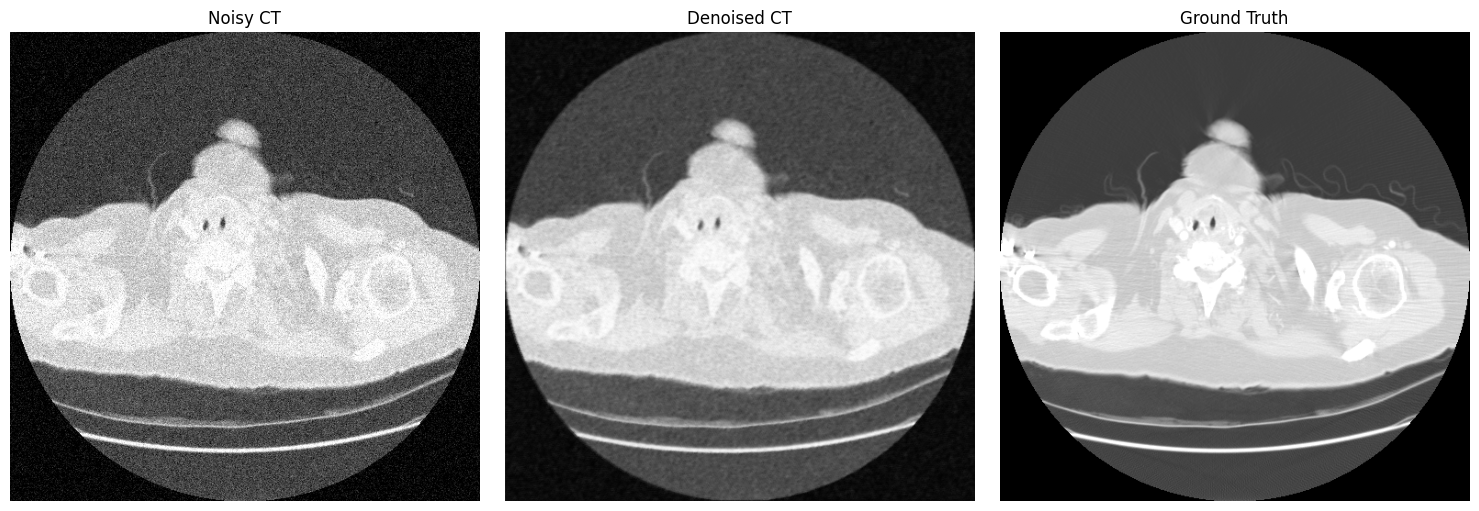

In [56]:
import matplotlib.pyplot as plt

# Convert tensor output to NumPy
denoised_image = output.detach().numpy().squeeze()

# Create comparison figure
fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Noisy image
axes[0].imshow(noisy_image.squeeze(), cmap='gray')
axes[0].set_title("Noisy CT")
axes[0].axis("off")

# Denoised image
axes[1].imshow(denoised_image, cmap='gray')
axes[1].set_title("Denoised CT")
axes[1].axis("off")

# Ground truth
axes[2].imshow(clean_norm.squeeze(), cmap='gray')
axes[2].set_title("Ground Truth")
axes[2].axis("off")

plt.tight_layout()

# Save figure
plt.savefig("../figures/denoising_results.png", dpi=300)

plt.show()